In [ ]:
#creating new variables

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data['new_charges']=data['charges'].apply(lambda x:x*2)
data['new_charges']

,new_charges
0,33769.84800
1,3451.10460
2,8898.92400
3,43968.94122
4,7733.71040
...,...
1333,21201.09660
1334,4411.96160
1335,3259.66700
1336,4015.89000


In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges,new_charges
0,19,female,27.900,0,yes,southwest,16884.92400,33769.84800
1,18,male,33.770,1,no,southeast,1725.55230,3451.10460
2,28,male,33.000,3,no,southeast,4449.46200,8898.92400
3,33,male,22.705,0,no,northwest,21984.47061,43968.94122
4,32,male,28.880,0,no,northwest,3866.85520,7733.71040


In [ ]:
#binnin technique

data['AgeGroup']=data['age'].apply(lambda x: 'young' if x<30 else 'Adult' if x<50 else 'senior')
data['AgeGroup']

,AgeGroup
0,young
1,young
2,young
3,Adult
4,Adult
...,...
1333,senior
1334,young
1335,young
1336,young


In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges,new_charges,AgeGroup
0,19,female,27.900,0,yes,southwest,16884.92400,33769.84800,young
1,18,male,33.770,1,no,southeast,1725.55230,3451.10460,young
2,28,male,33.000,3,no,southeast,4449.46200,8898.92400,young
3,33,male,22.705,0,no,northwest,21984.47061,43968.94122,Adult
4,32,male,28.880,0,no,northwest,3866.85520,7733.71040,Adult


In [ ]:
#one hot encoding

data=pd.get_dummies(data,columns=['smoker'], dtype=int)
data.head()

,age,sex,bmi,children,region,charges,new_charges,AgeGroup,smoker_no,smoker_yes
0,19,female,27.900,0,southwest,16884.92400,33769.84800,young,0,1
1,18,male,33.770,1,southeast,1725.55230,3451.10460,young,1,0
2,28,male,33.000,3,southeast,4449.46200,8898.92400,young,1,0
3,33,male,22.705,0,northwest,21984.47061,43968.94122,Adult,1,0
4,32,male,28.880,0,northwest,3866.85520,7733.71040,Adult,1,0


In [ ]:
x=data.copy()
x=pd.get_dummies(x, columns=['AgeGroup'], dtype='int')
x.head()

,age,sex,bmi,children,region,charges,new_charges,smoker_no,smoker_yes,AgeGroup_Adult,AgeGroup_senior,AgeGroup_young
0,19,female,27.900,0,southwest,16884.92400,33769.84800,0,1,0,0,1
1,18,male,33.770,1,southeast,1725.55230,3451.10460,1,0,0,0,1
2,28,male,33.000,3,southeast,4449.46200,8898.92400,1,0,0,0,1
3,33,male,22.705,0,northwest,21984.47061,43968.94122,1,0,1,0,0
4,32,male,28.880,0,northwest,3866.85520,7733.71040,1,0,1,0,0


In [ ]:
"""# prompt: #label encoding for female

# Label encoding for 'sex' column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x['sex'] = le.fit_transform(x['sex'])
x.head()"""


"# prompt: #label encoding for female\n\n# Label encoding for 'sex' column\nfrom sklearn.preprocessing import LabelEncoder\n\nle = LabelEncoder()\nx['sex'] = le.fit_transform(x['sex'])\nx.head()"

In [ ]:

#standardization

s_standardization = (data['age']-data['age'].mean())/data['age'].std()
print(s_standardization)

0      -1.438227
1      -1.509401
2      -0.797655
3      -0.441782
4      -0.512957
          ...   
1333    0.768185
1334   -1.509401
1335   -1.509401
1336   -1.295877
1337    1.551106
Name: age, Length: 1338, dtype: float64


In [ ]:
#normalize the series  (x-x.min()) / (x.max() - x.min())

s_normalized = (data['age'] - data['age'].min()) / (data['age'].max() - data['age'].min())
print(s_normalized)

0       0.021739
1       0.000000
2       0.217391
3       0.326087
4       0.304348
          ...   
1333    0.695652
1334    0.000000
1335    0.000000
1336    0.065217
1337    0.934783
Name: age, Length: 1338, dtype: float64


#Feature engineer techniques

# Log Transform

In [ ]:
# Log Transform

data_log =np.log(data['charges'])
data_log

,charges
0,9.734176
1,7.453302
2,8.400538
3,9.998092
4,8.260197
...,...
1333,9.268661
1334,7.698927
1335,7.396233
1336,7.604867


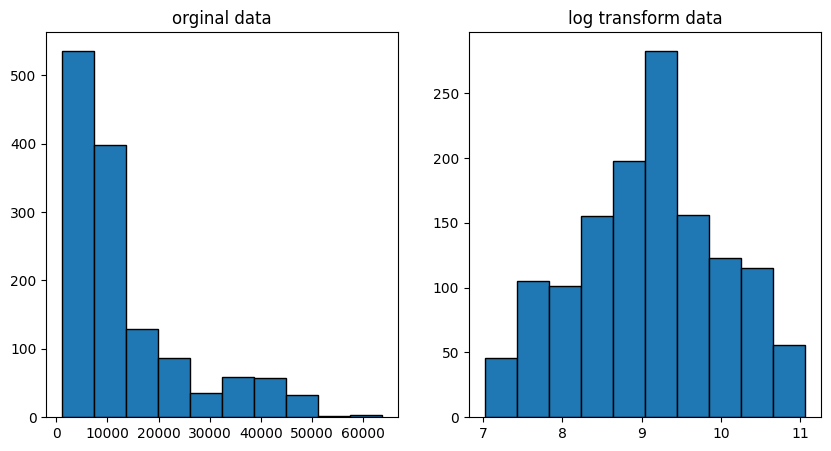

In [ ]:
#define a grid of plots
fig, ax = plt.subplots(1,2, figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(data['charges'], edgecolor='black')
plt.title('orginal data')

plt.subplot(1,2,2)
plt.hist(data_log, edgecolor='black')
plt.title( "log transform data")
#plt.tight_layout() #adjust subplot params for a tight layout
plt.show()

In [ ]:
"""
# Define a grid of plots
 fig, axs = plt.subplots(nrows=1, ncols=2)
 # Create histograms
 axs[0].hist(data[‘charges’], edgecolor=’black’)
 axs[1].hist(data_log, edgecolor=’black’)
 # Add a title to each histogram
 axs[0].set_title(‘Original Data’)
 axs[1].set_title(‘Log-Transformed Data’)
 # Display the plots
 plt.show()

"""

#Square root transform

In [ ]:
#Square root transform

data_sqrt=np.sqrt(data['charges'])
data_sqrt

,charges
0,129.942002
1,41.539768
2,66.704288
3,148.271611
4,62.184043
...,...
1333,102.958964
1334,46.967870
1335,40.371196
1336,44.810099


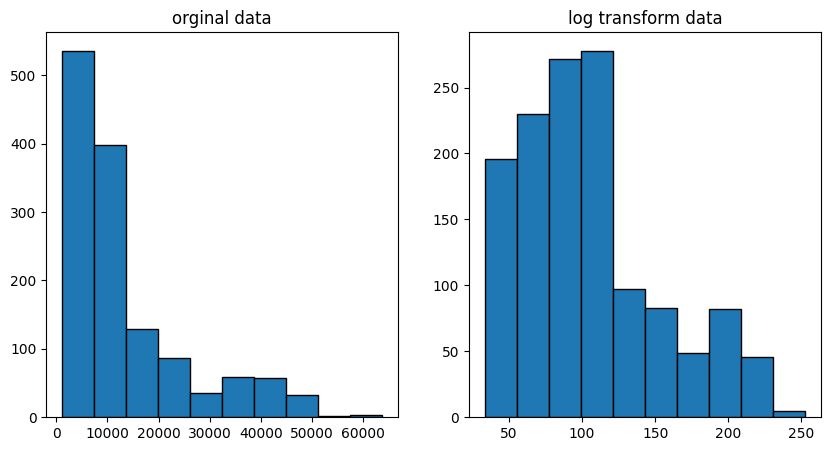

In [ ]:
fig, ax=plt.subplots(1,2, figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(data['charges'], edgecolor='black')
plt.title('orginal data')

plt.subplot(1,2,2)
plt.hist(data_sqrt, edgecolor='black')
plt.title( "log transform data")
#plt.tight_layout() #adjust subplot params for a tight layout
plt.show()

#Data Integration

#concatenation

In [ ]:
x={'col1':['a1','a2','a3','a4'],
   'col2':['b1','b2','b3','b4'],
   'col3':['c1','c2','c3','c4']}

y={'col1':['a5','a6','a7','a8'],
   'col2':['b5','b6','b7','b8'],
   'col3':['c5','c6','c7','c8']}



In [ ]:
df1=pd.DataFrame(x)
df2=pd.DataFrame(y)

In [ ]:
result=pd.concat([df1,df2], ignore_index=True)
result

,col1,col2,col3
0,a1,b1,c1
1,a2,b2,c2
2,a3,b3,c3
3,a4,b4,c4
4,a5,b5,c5
5,a6,b6,c6
6,a7,b7,c7
7,a8,b8,c8


In [ ]:
# The second code for concatenation shows missing columns in

df1 = pd.DataFrame({'Column1': ['A0', 'A1', 'A2'],
                    'Column2': ['B0', 'B1', 'B2'],
                    'Column3': ['D0', 'D1', 'D2'],
})

df2 = pd.DataFrame({'Column1': ['A3', 'A4', 'A5'],
                    'Column2': ['B3', 'B4', 'B5'],
                    'Column3': ['C3', 'C4', 'C5'],
                    'Column4': ['D3', 'D4', 'D5']
})

res1=pd.concat([df1,df2])
res1

,Column1,Column2,Column3,Column4
0,A0,B0,D0,NaN
1,A1,B1,D1,NaN
2,A2,B2,D2,NaN
0,A3,B3,C3,D3
1,A4,B4,C4,D4
2,A5,B5,C5,D5


In [ ]:
df1 = pd.DataFrame({'Column1': ['A0', 'A1', 'A2'],
                    'Column2': ['B0', 'B1', 'B2'],
                    'Column3': ['D0', 'D1', 'D2'],
})

df2 = pd.DataFrame({'Column3': ['C3', 'C4', 'C5'],
                    'Column4': ['D3', 'D4', 'D5']
})

res2=pd.concat([df1,df2], axis=1)
res2

,Column1,Column2,Column3,Column3,Column4
0,A0,B0,D0,C3,D3
1,A1,B1,D1,C4,D4
2,A2,B2,D2,C5,D5


In [ ]:
df1 = pd.DataFrame({'Column1': ['A0', 'A1', 'A2'],
                    'Column2': ['B0', 'B1', 'B2'],
                    'Column3': ['D0', 'D1', 'D2'],
})

df2 = pd.DataFrame({'Column3': ['C3', 'C4', 'C5'],
                    'Column4': ['D3', 'D4', 'D5']
})

res2=pd.concat([df1,df2], axis=0)
res2

,Column1,Column2,Column3,Column4
0,A0,B0,D0,NaN
1,A1,B1,D1,NaN
2,A2,B2,D2,NaN
0,NaN,NaN,C3,D3
1,NaN,NaN,C4,D4
2,NaN,NaN,C5,D5


#Merge

In [ ]:
df1=pd.DataFrame({
    'emp':['tom', 'ben', 'tom', 'suzy'],
    'Dep':['it','hr','it','hr']
})

df2=pd.DataFrame({
    'emp':['tom','suzy'],
    'salary':[1000,2000]
})

merge_df=pd.merge(df1,df2, on='emp')
merge_df


,emp,Dep,salary
0,tom,it,1000
1,tom,it,1000
2,suzy,hr,2000


In [ ]:
left_merge=pd.merge(df1, df2, on='emp', how='left')
left_merge

,emp,Dep,salary
0,tom,it,1000.0
1,ben,hr,NaN
2,tom,it,1000.0
3,suzy,hr,2000.0


#joins

In [ ]:
df1=pd.DataFrame({'a':['a0','a1','a2']}, index=['x','y','z'])
df2=pd.DataFrame({'b':['b0','b1','b2']}, index=['x','a','b'])

left_join=df1.join(df2)
left_join

,a,b
x,a0,b0
y,a1,NaN
z,a2,NaN


In [ ]:

right_join=df2.join(df1)
right_join

,b,a
x,b0,a0
a,b1,NaN
b,b2,NaN
